# 2. Feature engineering

Each recording is cut into non-overlapping 1-second windows, and each window is described by a small set of time-domain and spectral features. This notebook checks what those features actually measure before any model sees them.

The features are built by `scripts/build_features.py` and stored in `data/processed/features.parquet`, so this notebook runs without the raw data.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import features as ft
import leakdata as ld
import plotstyle as ps

ps.apply()
pd.set_option("display.width", 200)
feats = pd.read_parquet(ld.PROCESSED / "features.parquet")
feats = feats[feats.leak != "BG"].reset_index(drop=True)
ALL = ft.AMPLITUDE_FEATURES + ft.SHAPE_FEATURES

summary = feats.groupby("sensor_type").agg(recordings=("file", "nunique"), windows=("file", "size"))
summary["windows per recording"] = (summary.windows / summary.recordings).round(1)
summary.rename(index=ld.SENSOR_NAMES).reindex([ld.SENSOR_NAMES[s] for s in "APH"])

,recordings,windows,windows per recording
sensor_type,,,
Accelerometer,80,2859,35.7
Dynamic pressure,80,2890,36.1
Hydrophone,120,4572,38.1


## 2.1 The feature set

| Group | Features | What they describe |
|---|---|---|
| Level | `log_rms` | Absolute signal level. The only feature that changes if the signal is scaled. |
| Waveform shape | `kurtosis`, `skew`, `crest`, `zcr`, `block_cv` | Impulsiveness, asymmetry, peak-to-RMS ratio, zero-crossing rate, and how much the level varies inside the window. |
| Spectrum summary | `f_centroid`, `f_spread`, `f_peak`, `f50`, `f95`, `spec_entropy`, `spec_flatness` | Where the energy sits and how spread out or tonal it is. |
| Band energies | `band_0` to `band_9` | Log share of energy in ten bands. |

The band edges differ by sensor type, because the hydrophone is sampled at 8 kHz and carries nearly all its energy below 100 Hz:

In [2]:
pd.DataFrame({ld.SENSOR_NAMES[s]: [f"{lo}-{hi} Hz" for lo, hi in zip(ft.BANDS[s][:-1], ft.BANDS[s][1:])] for s in "APH"},
             index=ft.BAND_COLS)

,Accelerometer,Dynamic pressure,Hydrophone
band_0,0-20 Hz,0-20 Hz,0-5 Hz
band_1,20-50 Hz,20-50 Hz,5-10 Hz
band_2,50-100 Hz,50-100 Hz,10-20 Hz
band_3,100-200 Hz,100-200 Hz,20-50 Hz
band_4,200-500 Hz,200-500 Hz,50-100 Hz
band_5,500-1000 Hz,500-1000 Hz,100-200 Hz
band_6,1000-2000 Hz,1000-2000 Hz,200-500 Hz
band_7,2000-4000 Hz,2000-4000 Hz,500-1000 Hz
band_8,4000-8000 Hz,4000-8000 Hz,1000-2000 Hz
band_9,8000-12800 Hz,8000-12800 Hz,2000-4000 Hz


Level is kept as one separate feature on purpose. Notebook 1 showed that level mostly encodes which sensor and layout a recording came from. Every other feature is scale-invariant, so models can be trained with and without level to measure what it contributes.

## 2.2 Windows from one recording are near-copies of each other

For each feature, the share of its variance that lies between recordings rather than between windows of the same recording. A value near 1 means every window of a recording carries almost the same number.

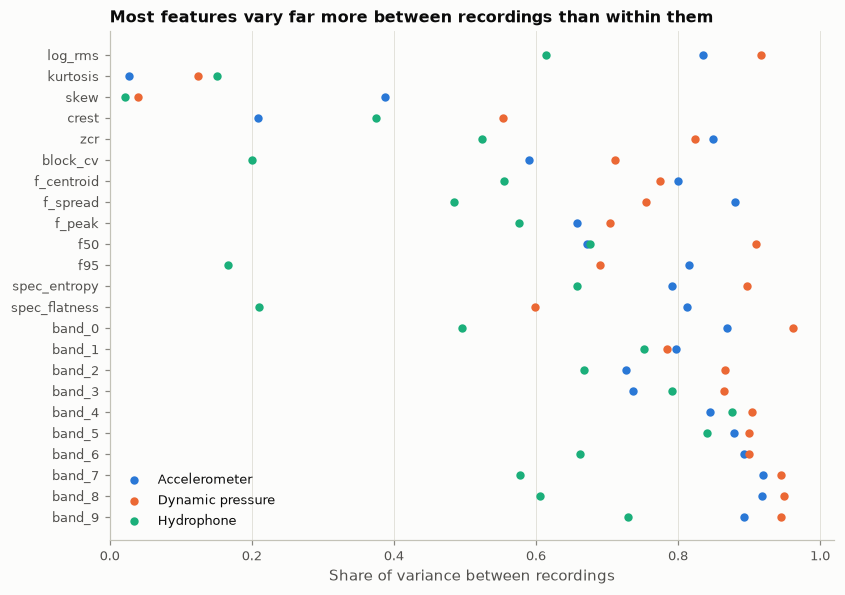

Median share between recordings: {'Accelerometer': 0.81, 'Dynamic pressure': 0.87, 'Hydrophone': 0.58}


In [3]:
def between_share(d, col):
    return d.groupby("file")[col].mean().var(ddof=0) / d[col].var(ddof=0)

icc = pd.DataFrame({ld.SENSOR_NAMES[s]: {c: between_share(feats[feats.sensor_type == s], c) for c in ALL} for s in "APH"})
fig, ax = plt.subplots(figsize=(8.5, 6))
y = np.arange(len(ALL))
for i, (name, color) in enumerate(zip(icc.columns, ["#2a78d6", "#eb6834", "#1baf7a"])):
    ax.scatter(icc[name], y, s=30, color=color, label=name, zorder=3, linewidths=0)
ax.set_yticks(y, ALL)
ax.invert_yaxis()
ax.set_xlim(0, 1.02)
ax.set_xlabel("Share of variance between recordings")
ax.set_title("Most features vary far more between recordings than within them")
ax.legend(loc="lower left")
ax.grid(axis="y", visible=False)
plt.show()
print("Median share between recordings:", {k: round(float(v), 2) for k, v in icc.median().items()})

For the accelerometer and pressure sensors, a typical feature has more than 80% of its variance between recordings (median 0.81 and 0.87). Thirty-six windows from one recording are close to thirty-six copies of the same point. The hydrophone is less extreme (0.58) because its level wanders more within a recording.

This is why a random split of windows is not a valid test here. A model can recognise the recording a window came from and look up its label, and that will look like accuracy. Notebook 3 measures how large that effect is.

## 2.3 What each feature tracks

Share of each feature's variance explained by one factor at a time. The last two columns ask the question that matters: within a single layout, and after removing the difference between sensor 1 and sensor 2, how much does leak class explain?

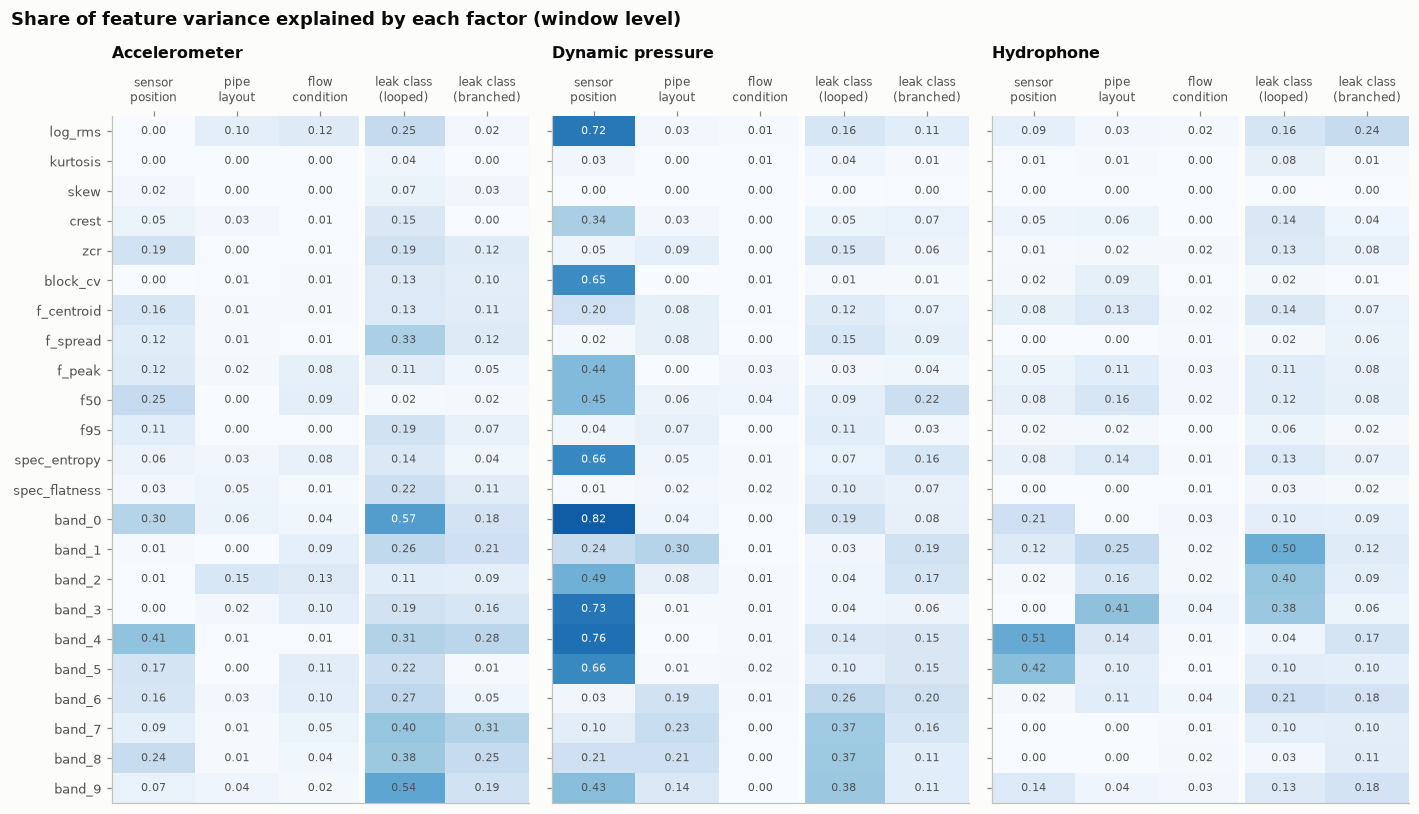

Median across the scale-invariant features:
                       Accelerometer  Dynamic pressure  Hydrophone
sensor position                 0.10              0.29        0.02
pipe layout                     0.01              0.05        0.07
flow condition                  0.03              0.01        0.01
leak class (looped)             0.19              0.10        0.11
leak class (branched)           0.11              0.08        0.08


In [4]:
def eta2(values, groups):
    values = np.asarray(values, float)
    means = pd.Series(values).groupby(np.asarray(groups)).transform("mean").to_numpy()
    return ((means - values.mean()) ** 2).sum() / ((values - values.mean()) ** 2).sum()

def leak_within(d, col, topo):
    d = d[d.topology == topo]
    resid = d[col] - d.groupby("sensor")[col].transform("mean")
    return eta2(resid, d.leak)

tables = {}
for s in "APH":
    d = feats[feats.sensor_type == s]
    tables[s] = pd.DataFrame(
        {
            "sensor\nposition": [eta2(d[c], d.sensor) for c in ALL],
            "pipe\nlayout": [eta2(d[c], d.topology) for c in ALL],
            "flow\ncondition": [eta2(d[c], d.flow) for c in ALL],
            "leak class\n(looped)": [leak_within(d, c, "LO") for c in ALL],
            "leak class\n(branched)": [leak_within(d, c, "BR") for c in ALL],
        },
        index=ALL,
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 7.5), sharey=True)
for ax, s in zip(axes, "APH"):
    t = tables[s]
    im = ax.imshow(t.to_numpy(), cmap=ps.SEQ_CMAP, vmin=0, vmax=1, aspect="auto")
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.55 else ps.INK_2)
    ax.set_xticks(range(t.shape[1]), t.columns, fontsize=8)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(ALL)), ALL)
    ax.set_title(ld.SENSOR_NAMES[s], pad=38)
    ax.grid(False)
    ax.axvline(2.5, color=ps.SURFACE, lw=4)
fig.suptitle("Share of feature variance explained by each factor (window level)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

print("Median across the scale-invariant features:")
print(pd.DataFrame({ld.SENSOR_NAMES[s]: tables[s].loc[ft.SHAPE_FEATURES].median() for s in "APH"}).rename(index=lambda c: c.replace("\n", " ")).round(2).to_string())

Reading across the columns:

- **Pressure features mostly identify the sensor.** Sensor position explains 72% of the variance in level and 82% in the lowest band; the median over the scale-invariant features is 0.29. Removing level does not remove the position signal, because P1 and P2 also have different spectra.
- **Flow condition explains very little** of the scale-invariant features on its own (median 0.01 to 0.03).
- **Leak class explains more in the looped layout than in the branched layout** on the median feature, for every sensor type. The largest values are in the accelerometer bands (0.57 in the lowest band, 0.54 in the highest), which is where the interference pattern from notebook 1 shows up.

### Is the leak effect larger than chance?

With only four tests per class in each layout, and windows that are near-copies within a test, some variance will be "explained" by leak class even if the labels mean nothing. To measure that floor, the class labels are shuffled between the 20 tests of a layout (keeping all windows of a test together) and the same statistic is recomputed 500 times.

In [5]:
def leak_eta_all(d, labels):
    """Leak-class eta squared for every scale-invariant feature, given one label per row."""
    x = d[ft.SHAPE_FEATURES].to_numpy(float)
    x = x - x.mean(axis=0)
    codes = pd.factorize(labels)[0]
    onehot = np.eye(codes.max() + 1)[codes]
    means = (onehot.T @ x) / onehot.sum(axis=0)[:, None]
    return (onehot.sum(axis=0)[:, None] * means**2).sum(axis=0) / (x**2).sum(axis=0)

rng = np.random.default_rng(0)
rows = []
for s in "APH":
    for topo in ["LO", "BR"]:
        d = feats[(feats.sensor_type == s) & (feats.topology == topo)].copy()
        d[ft.SHAPE_FEATURES] = d[ft.SHAPE_FEATURES] - d.groupby("sensor")[ft.SHAPE_FEATURES].transform("mean")
        observed = leak_eta_all(d, d.leak.to_numpy())
        conditions = np.sort(d.condition.unique())
        true = np.array([c.split("|")[1] for c in conditions])
        null = np.array([leak_eta_all(d, d.condition.map(dict(zip(conditions, rng.permutation(true)))).to_numpy()) for _ in range(500)])
        rows.append({"sensor type": ld.SENSOR_NAMES[s], "layout": ld.TOPOLOGIES[topo],
                     "observed": np.median(observed),
                     "shuffled, median": np.median(np.median(null, axis=1)),
                     "shuffled, 95th pct": np.percentile(np.median(null, axis=1), 95),
                     "features above 95th pct": f"{int((observed > np.percentile(null, 95, axis=0)).sum())} of {len(observed)}"})
pd.DataFrame(rows).set_index(["sensor type", "layout"]).round(3)

observed  shuffled, median  shuffled, 95th pct features above 95th pct
sensor type      layout                                                                          
Accelerometer    Looped       0.192             0.076               0.136                13 of 22
                 Branched     0.106             0.053               0.085                 7 of 22
Dynamic pressure Looped       0.101             0.049               0.098                 9 of 22
                 Branched     0.083             0.037               0.067                12 of 22
Hydrophone       Looped       0.108             0.037               0.066                14 of 22
                 Branched     0.077             0.045               0.075                 9 of 22

The observed leak effect is above the 95th percentile of the shuffled-label distribution in all six cases, and between 7 and 14 of the 22 features exceed their own threshold where about one would be expected by chance. So the features do carry class-related information that is not just noise from having few tests.

Two cautions on how far that goes:

- **The margin is small in the branched layout** (for example 0.077 against a threshold of 0.075 for the hydrophone). Roughly half of the apparent effect is the chance floor.
- **Beating shuffled labels does not show the cause is the leak.** If all tests of one class were recorded together, anything that changed between sessions (sensor mounting, pump state, electrical noise) is tied to the class label just as tightly as the leak is. This test cannot tell those apart. Testing across layouts and flow conditions can, and that is what notebook 3 does.

## 2.4 The same features, class by class

Four accelerometer features, one dot per recording (the median over its windows). Circles are the looped layout, squares the branched layout.

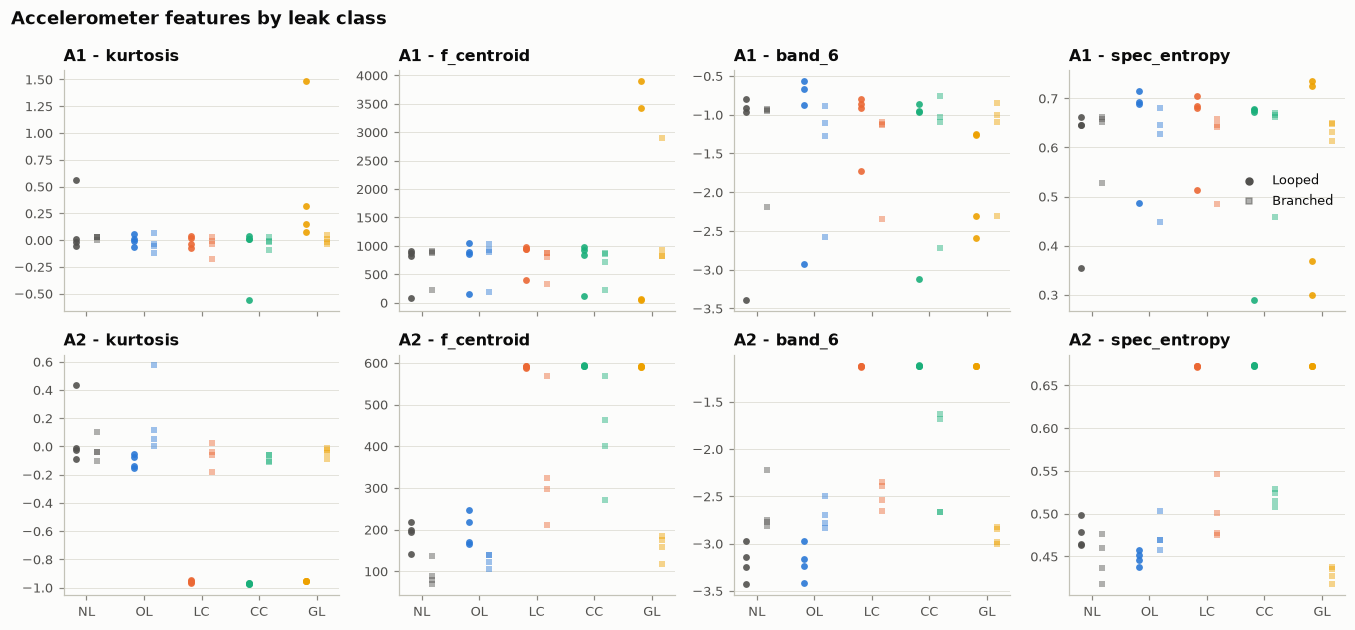

In [6]:
def dot_panels(stype, cols, title):
    rec = feats[feats.sensor_type == stype].groupby(["file", "sensor", "topology", "leak"], observed=True)[cols].median().reset_index()
    sensors = sorted(rec.sensor.unique())
    fig, axes = plt.subplots(len(sensors), len(cols), figsize=(3.1 * len(cols), 2.9 * len(sensors)), sharex=True, squeeze=False)
    for r, sensor in enumerate(sensors):
        for c, col in enumerate(cols):
            ax = axes[r, c]
            for i, leak in enumerate(ld.LEAKS):
                for j, (topo, marker, alpha) in enumerate([("LO", "o", 0.9), ("BR", "s", 0.45)]):
                    v = rec[(rec.sensor == sensor) & (rec.leak == leak) & (rec.topology == topo)][col]
                    ax.scatter(np.full(len(v), i + (j - 0.5) * 0.36), v, s=20, marker=marker, color=ps.LEAK_COLORS[leak], alpha=alpha, linewidths=0)
            ax.set_xticks(range(5), ld.LEAKS)
            ax.set_title(f"{sensor} - {col}")
            ax.grid(axis="x", visible=False)
    axes[0, -1].scatter([], [], marker="o", color=ps.INK_2, s=20, label="Looped")
    axes[0, -1].scatter([], [], marker="s", color=ps.INK_2, s=20, alpha=0.45, label="Branched")
    axes[0, -1].legend(loc="best")
    fig.suptitle(title, x=0.01, ha="left", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

dot_panels("A", ["kurtosis", "f_centroid", "band_6", "spec_entropy"], "Accelerometer features by leak class")

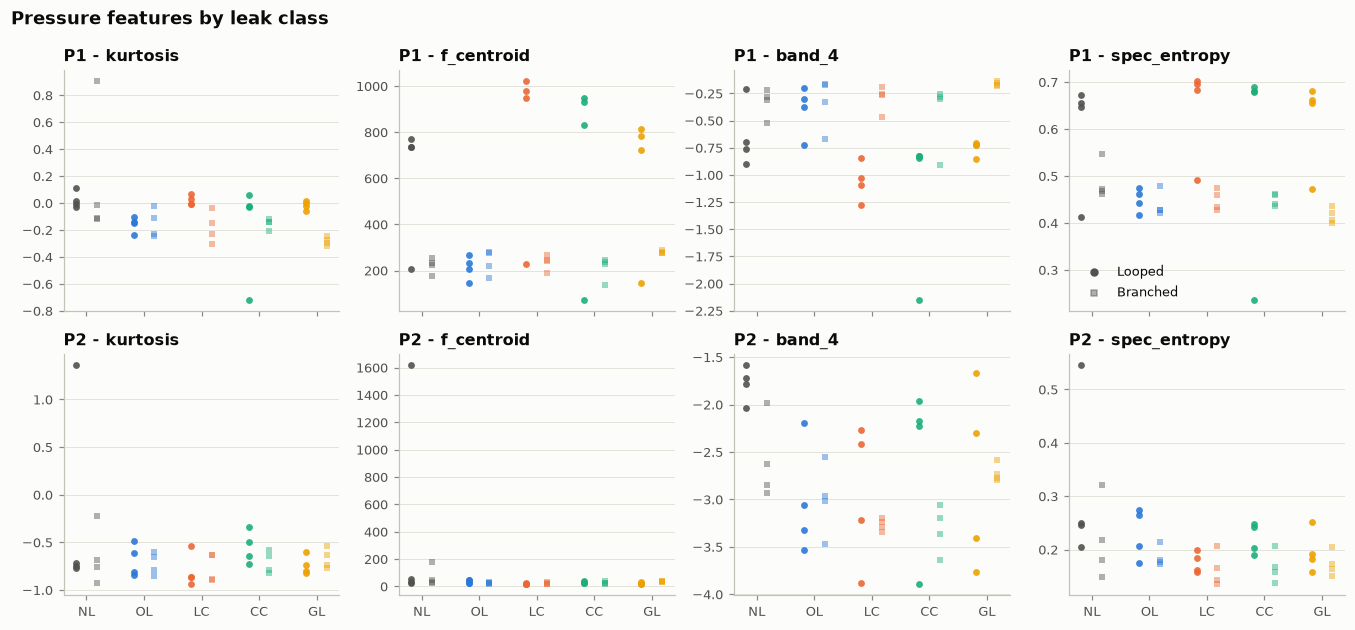

In [7]:
dot_panels("P", ["kurtosis", "f_centroid", "band_4", "spec_entropy"], "Pressure features by leak class")

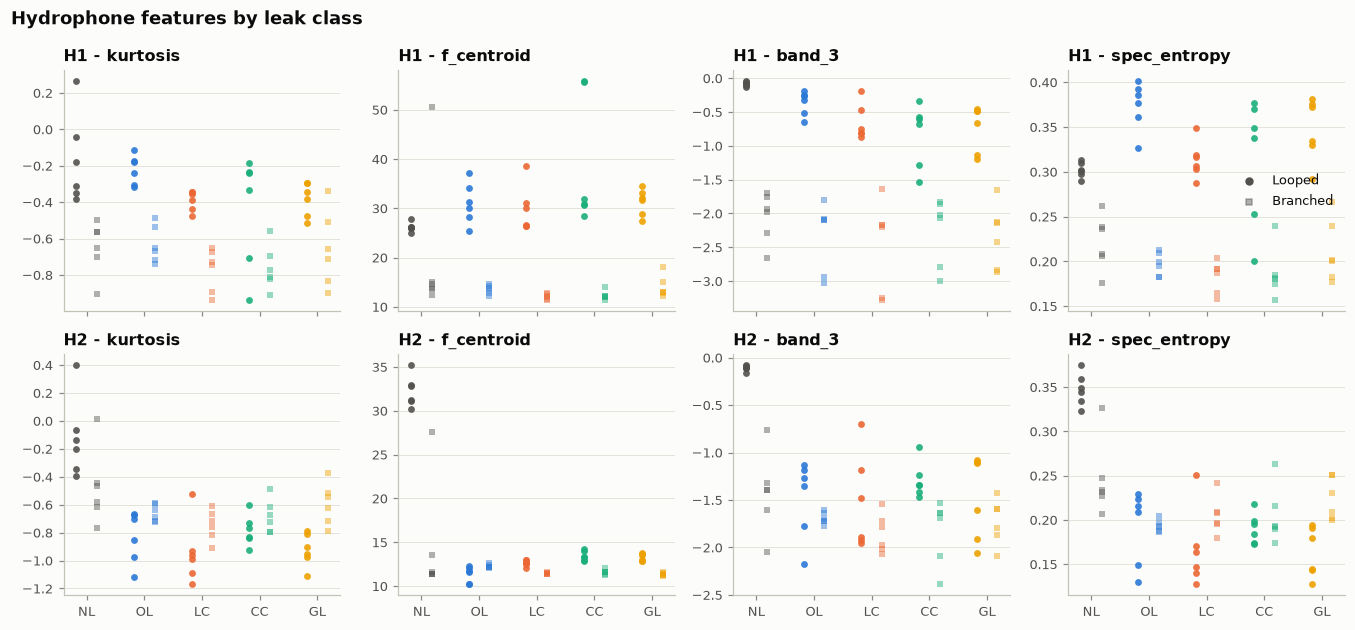

In [8]:
dot_panels("H", ["kurtosis", "f_centroid", "band_3", "spec_entropy"], "Hydrophone features by leak class")

- **Accelerometer A2, looped:** the two cracks and the gasket leak collapse onto a single value for every feature (kurtosis -0.95, centroid 590 Hz), with no spread across flow conditions. This is the interference pattern, seen as features. In the branched layout the same classes spread out and overlap with the others.
- **Pressure P1, looped:** the cracks and gasket leak have a centroid near 900 Hz against about 200 Hz for the orifice leak, and no-leak is split between the two. None of that separation appears in the branched layout.
- **Hydrophone H2, looped:** no-leak stands apart (centroid about 32 Hz against about 12 Hz for every leak class). This is the cleanest-looking leak versus no-leak contrast in the dataset. In the branched layout it shrinks to a single recording.

In every case the contrast that separates classes in one layout is absent or much weaker in the other.

## 2.5 The feature space in two dimensions

Principal components of the scale-invariant features, one row per sensor type. The same points are coloured three ways: by leak class, by sensor and layout, and by flow condition.

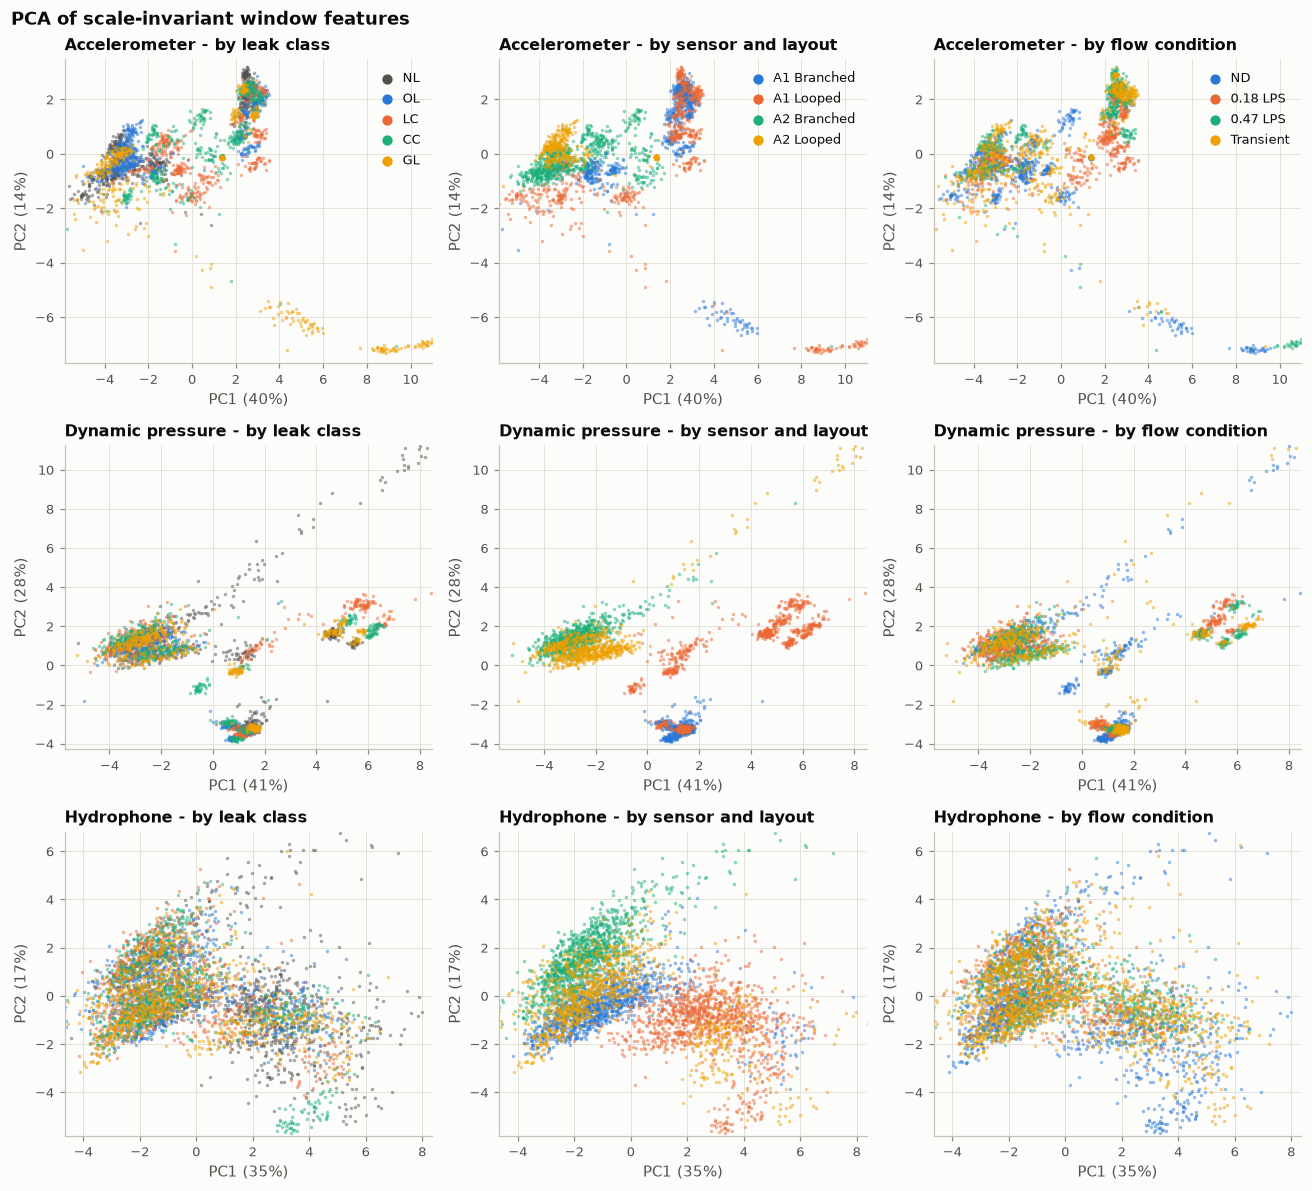

In [9]:
CONTEXT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for r, s in enumerate("APH"):
    d = feats[feats.sensor_type == s].sample(frac=1, random_state=0)
    pca = PCA(2).fit(StandardScaler().fit_transform(d[ft.SHAPE_FEATURES]))
    z = pca.transform(StandardScaler().fit_transform(d[ft.SHAPE_FEATURES]))
    context = d.sensor + " " + d.topology.map(ld.TOPOLOGIES)
    colourings = [
        ("leak class", d.leak, ld.LEAKS, [ps.LEAK_COLORS[k] for k in ld.LEAKS]),
        ("sensor and layout", context, sorted(context.unique()), CONTEXT_COLORS),
        ("flow condition", d.flow, ld.FLOWS, CONTEXT_COLORS),
    ]
    for c, (name, labels, order, colors) in enumerate(colourings):
        ax = axes[r, c]
        for key, color in zip(order, colors):
            m = (labels == key).to_numpy()
            ax.scatter(z[m, 0], z[m, 1], s=5, color=color, alpha=0.5, linewidths=0, label=key, rasterized=True)
        ax.set_xlim(np.percentile(z[:, 0], [0.5, 99.5]) + np.array([-0.5, 0.5]))
        ax.set_ylim(np.percentile(z[:, 1], [0.5, 99.5]) + np.array([-0.5, 0.5]))
        ax.set_title(f"{ld.SENSOR_NAMES[s]} - by {name}")
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
        if r == 0:
            leg = ax.legend(loc="best", markerscale=3, handletextpad=0.2)
            for h in leg.legend_handles:
                h.set_alpha(1)
fig.suptitle("PCA of scale-invariant window features", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

To put a number on what the plots show, a nearest-neighbour classifier is given only the two principal components and asked to recover each labelling, always predicting windows from recordings it has not seen.

In [10]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier

rows = []
for s in "APH":
    d = feats[feats.sensor_type == s]
    z = PCA(2).fit_transform(StandardScaler().fit_transform(d[ft.SHAPE_FEATURES]))
    row = {"sensor type": ld.SENSOR_NAMES[s]}
    for name, labels in [("sensor and layout (chance 0.25)", d.sensor + d.topology), ("flow condition (chance 0.25)", d.flow), ("leak class (chance 0.20)", d.leak)]:
        pred = cross_val_predict(KNeighborsClassifier(15), z, labels.to_numpy(), groups=d.file.to_numpy(), cv=GroupKFold(5))
        row[name] = balanced_accuracy_score(labels, pred)
    rows.append(row)
print("Balanced accuracy of a 15-nearest-neighbour classifier on the two principal components")
pd.DataFrame(rows).set_index("sensor type").round(2)

Balanced accuracy of a 15-nearest-neighbour classifier on the two principal components


,sensor and layout (chance 0.25),flow condition (chance 0.25),leak class (chance 0.20)
sensor type,,,
Accelerometer,0.71,0.21,0.39
Dynamic pressure,0.78,0.36,0.25
Hydrophone,0.69,0.23,0.28


The two main directions of variation say far more about which sensor and layout a window came from than about its leak class: sensor and layout are recovered with 0.69 to 0.78 balanced accuracy, leak class with 0.25 to 0.39. The groups are not cleanly separated clusters, particularly for the accelerometer, but the ordering is the same for all three sensor types.

One detail in the accelerometer row: a single dense amber dot near the centre of the middle panel is all 432 windows of the twelve looped A2 crack and gasket recordings, sitting on one point.

## 2.6 Summary

- Each recording gives about 36 one-second windows described by 23 features: one for level and 22 that are independent of scale.
- Windows from the same recording are near-duplicates, so the effective sample size is the number of physical tests (40), not the number of windows (about 10,000).
- The features say more about sensor position and pipe layout than about leak class. Leak class has a measurable effect beyond chance, larger in the looped layout, but this analysis cannot separate a leak effect from a session effect.
- The modelling therefore has to be judged on held-out tests, held-out flow conditions and, above all, a held-out layout.